# Weather Data Analysis

Analyzing GFS cache for cell 46_13 (Kobala region).

In [3]:
import sys
import os
import glob
sys.path.append(os.path.abspath("../src"))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from paraglideml.data.weather_cache import WeatherCache
%matplotlib inline
sns.set_theme(style="whitegrid")

In [4]:
cache_root = "../data/gfs/cache"
print(f"Checking cache root: {os.path.abspath(cache_root)}")
if not os.path.exists(cache_root):
    print("ERROR: Cache directory not found!")
else:
    print("Cache directory exists.")
    # List some files to verify
    files = glob.glob(f"{cache_root}/cells/46_13/2024/06/*.npz")
    print(f"Found {len(files)} files for 2024/06 in 46_13")

Checking cache root: /home/gena/dev/paraglideml/data/gfs/cache
Cache directory exists.
Found 90 files for 2024/06 in 46_13


In [3]:
cache = WeatherCache(cache_root=cache_root)
LAT, LON = 46, 13
dates = pd.date_range("2024-06-01", "2024-06-30")
data_points = []

for d in dates:
    # Try loading 12:00 UTC
    s = cache.load_sample(LAT, LON, d, 12)
    if s:
        f = s["features"]
        f["date"] = d
        data_points.append(f)

df_w = pd.DataFrame(data_points)
print(f"Loaded {len(df_w)} days.")
print(df_w.head())

Loaded 30 days.
   surface_pressure     temp_2m     u_10m     v_10m  wind_speed_10m  \
0     100512.945312  292.976349  0.921707  1.153403        1.476442   
1     100765.804688  296.399994 -1.515039  2.320840        2.771577   
2     100584.812500  292.307861  2.325586 -0.022175        2.325692   
3     100698.929688  294.752014 -0.485364  3.363919        3.398754   
4     100836.109375  296.309479  0.829484  2.623376        2.751390   

   wind_speed_850  wind_speed_700  wind_shear_low   dps_850   dps_700  ...  \
0        2.995934        8.963014        1.534988  0.300000  7.280000  ...   
1        3.041366        2.262423        0.677139  2.220000  8.160000  ...   
2        2.807635        3.130245        4.830934  3.980000  5.339999  ...   
3        3.253234        5.311569        2.361335  3.360001  2.500000  ...   
4        2.445185        1.498895        0.691170  2.380000  7.060001  ...   

     ws_800  lr_800_750    ws_750  lr_750_700    ws_700  lr_700_600  \
0  4.027006    2.

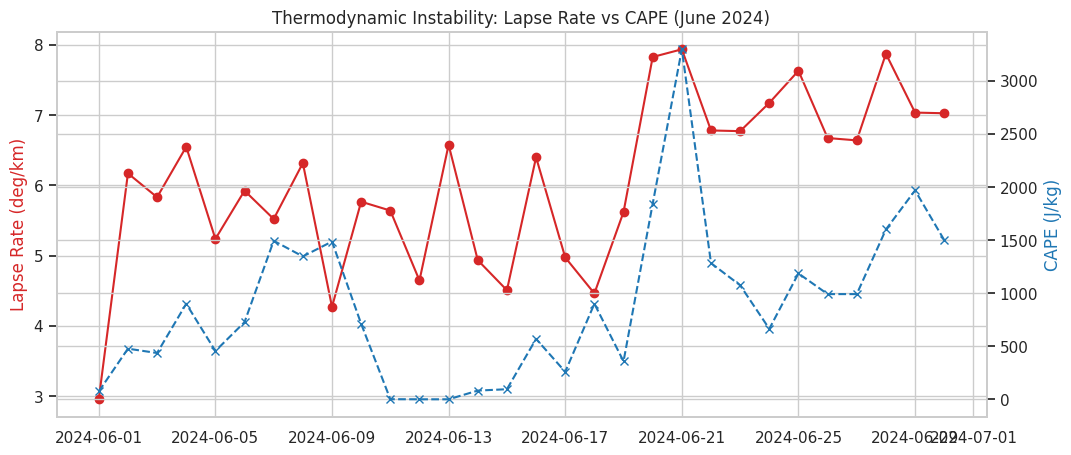

In [4]:
if not df_w.empty:
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(df_w["date"], df_w["lr_800_750"], color="tab:red", label="Lapse Rate (Low)", marker='o')
    ax1.set_ylabel("Lapse Rate (deg/km)", color="tab:red")
    
    ax2 = ax1.twinx()
    ax2.plot(df_w["date"], df_w["cape"], color="tab:blue", linestyle="--", label="CAPE", marker='x')
    ax2.set_ylabel("CAPE (J/kg)", color="tab:blue")
    
    plt.title("Thermodynamic Instability: Lapse Rate vs CAPE (June 2024)")
    plt.show()

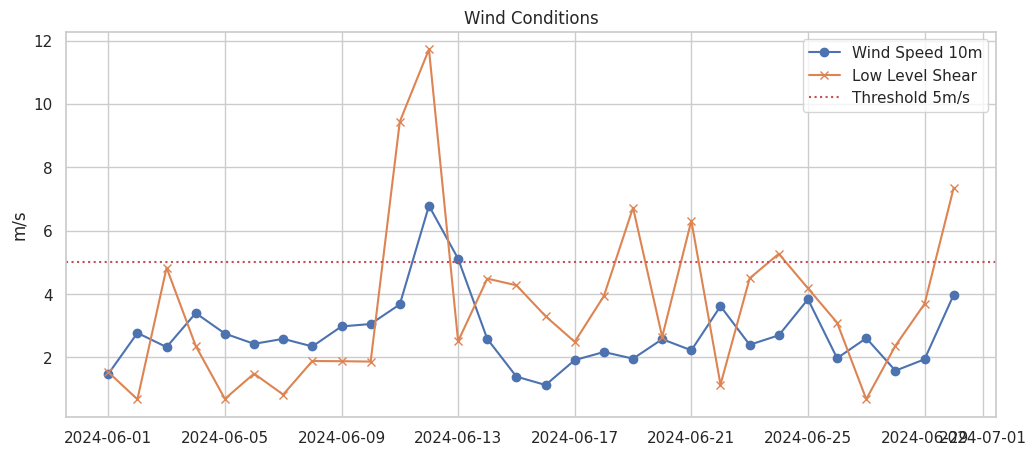

In [5]:
if not df_w.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(df_w["date"], df_w["wind_speed_10m"], label="Wind Speed 10m", marker='o')
    plt.plot(df_w["date"], df_w["wind_shear_low"], label="Low Level Shear", marker='x')
    plt.axhline(5, color='r', linestyle=':', label='Threshold 5m/s')
    plt.title("Wind Conditions")
    plt.ylabel("m/s")
    plt.legend()
    plt.show()